In [1]:
import numpy as np
import rydcalc
import tqdm
import scipy.constants as cs
import dill as pickle   
import itertools
import math
import matplotlib.pyplot as plt
# Add the missing attribute back manually
rydcalc.large_search.fix_libs()


In [2]:
Yb171 = rydcalc.Ytterbium171(cpp_numerov=True, use_db=False)
Rb = rydcalc.Rubidium87(cpp_numerov=True, use_db=False)

theta = 0
Bz = 10
rList_um = np.arange(2, 10, 0.05)

def include_fn_strict(p, p0):
    return abs(p0.energy_Hz - p.energy_Hz) < 3e9 and ((-1)**(p.s1.channels[0].l + p.s2.channels[0].l)==(-1)**(p0.s1.channels[0].l + p0.s2.channels[0].l))
opts = {
    'dn': 5,
    'dl': 3,
    'dm': 3,
    'dipole_allowed': False,
    'pair_include_fn': include_fn_strict
}

st_yb = Yb171.get_state((53.30, 0, 0.5, 0.5))
st_rb = Rb.get_state((58, 0, 0.5, 0.5))



In [ ]:
pb = rydcalc.pair_basis_pre_computation()
pb.fill(rydcalc.pair(st_yb, st_yb), include_opts=opts)
print(pb.dim())
pb.computeHamiltonians(multipoles=[[1,1]])

pair_int = rydcalc.analysis_pair_interaction(st_yb, pb=pb, include_opts=opts)

result = pair_int.run(rList_um=rList_um, th=0, Bz_Gauss=Bz)

fig,axs = pair_int.pa_plot(include_plot_opts = {'ov_norm': 'log', 'log_norm': [0.01,1]})
axs[1].set_ylim(-300,150)

axs[1].set_title(f"{st_yb}")
ybyb_x_2 = axs[0].lines[0].get_xdata()
ybyb_y_2 = axs[0].lines[0].get_ydata()
print(ybyb_x_2)
plt.show()

8485
computed diagonal elements in 0.006606199953239411 s


68
computed diagonal elements in 1.791700000808305e-05 s
computed HEz and Hint in 0.016219165999999063 s
computed HBz in 0.020098124999989864 s
computed HBdiam in 0.0384639170000014 s


100%|██████████| 160/160 [00:00<00:00, 2345.81it/s]


[2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65
 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35
 3.4  3.45 3.5  3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05
 4.1  4.15 4.2  4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75
 4.8  4.85 4.9  4.95 5.   5.05 5.1  5.15 5.2  5.25 5.3  5.35 5.4  5.45
 5.5  5.55 5.6  5.65 5.7  5.75 5.8  5.85 5.9  5.95 6.   6.05 6.1  6.15
 6.2  6.25 6.3  6.35 6.4  6.45 6.5  6.55 6.6  6.65 6.7  6.75 6.8  6.85
 6.9  6.95 7.   7.05 7.1  7.15 7.2  7.25 7.3  7.35 7.4  7.45 7.5  7.55
 7.6  7.65 7.7  7.75 7.8  7.85 7.9  7.95 8.   8.05 8.1  8.15 8.2  8.25
 8.3  8.35 8.4  8.45 8.5  8.55 8.6  8.65 8.7  8.75 8.8  8.85 8.9  8.95
 9.   9.05 9.1  9.15 9.2  9.25 9.3  9.35 9.4  9.45 9.5  9.55 9.6  9.65
 9.7  9.75 9.8  9.85 9.9  9.95]


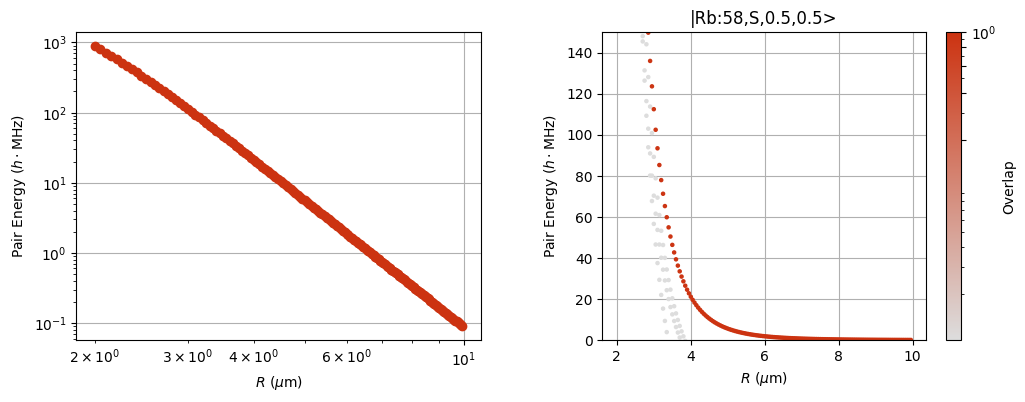

In [4]:
pb = rydcalc.pair_basis_pre_computation()
pb.fill(rydcalc.pair(st_rb, st_rb), include_opts=opts)
print(pb.dim())
pb.computeHamiltonians(multipoles=[[1,1]])

pair_int = rydcalc.analysis_pair_interaction(st_rb, pb=pb, include_opts=opts)

result = pair_int.run(rList_um=rList_um, th=0, Bz_Gauss=Bz)

fig,axs = pair_int.pa_plot(include_plot_opts = {'ov_norm': 'log', 'log_norm': [0.01,1]})
axs[1].set_ylim(0,150)
axs[1].set_title(f"{st_rb}")
rbrb_x_2 = axs[0].lines[0].get_xdata()
rbrb_y_2 = axs[0].lines[0].get_ydata()
print(rbrb_x_2)
plt.show()

322
computed diagonal elements in 3.4165999991842e-05 s
computed HEz and Hint in 0.7477905000000078 s
computed HBz in 0.5393552919999962 s
computed HBdiam in 0.5664469170000075 s
Basis size: 322


100%|██████████| 160/160 [00:00<00:00, 173.50it/s]


[2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65
 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35
 3.4  3.45 3.5  3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05
 4.1  4.15 4.2  4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75
 4.8  4.85 4.9  4.95 5.   5.05 5.1  5.15 5.2  5.25 5.3  5.35 5.4  5.45
 5.5  5.55 5.6  5.65 5.7  5.75 5.8  5.85 5.9  5.95 6.   6.05 6.1  6.15
 6.2  6.25 6.3  6.35 6.4  6.45 6.5  6.55 6.6  6.65 6.7  6.75 6.8  6.85
 6.9  6.95 7.   7.05 7.1  7.15 7.2  7.25 7.3  7.35 7.4  7.45 7.5  7.55
 7.6  7.65 7.7  7.75 7.8  7.85 7.9  7.95 8.   8.05 8.1  8.15 8.2  8.25
 8.3  8.35 8.4  8.45 8.5  8.55 8.6  8.65 8.7  8.75 8.8  8.85 8.9  8.95
 9.   9.05 9.1  9.15 9.2  9.25 9.3  9.35 9.4  9.45 9.5  9.55 9.6  9.65
 9.7  9.75 9.8  9.85 9.9  9.95]


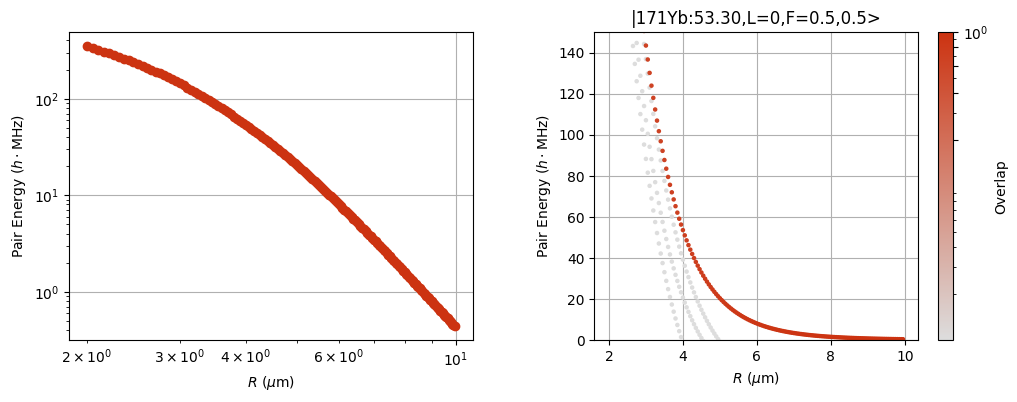

In [5]:
pb = rydcalc.pair_basis_pre_computation()
pb.fill(rydcalc.pair(st_yb, st_rb), include_opts=opts)
print(pb.dim())
pb.computeHamiltonians(multipoles=[[1,1]])

pair_int = rydcalc.analysis_pair_interaction(st_yb, st_rb, include_opts=opts)

result = pair_int.run(rList_um=rList_um, th=0, Bz_Gauss=Bz)

fig,axs = pair_int.pa_plot(include_plot_opts = {'ov_norm': 'log', 'log_norm': [0.01,1]})
axs[1].set_ylim(0,150)
# axs[1].set_title(f"{st_rb}, {st_yb}")
axs[1].set_title(f"{st_yb}")
ybrb_x_2 = axs[0].lines[0].get_xdata()
ybrb_y_2 = axs[0].lines[0].get_ydata()
print(rbrb_x_2)
plt.show()

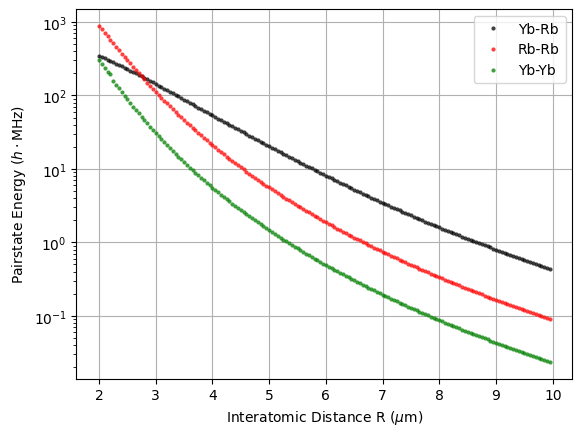

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(ybrb_x_2, ybrb_y_2, '.k', alpha=.75, label='Yb-Rb', markeredgecolor='none')
# ax.plot(ybrb_x, ybrb_y, '-k', alpha=0.5)

ax.plot(rbrb_x_2, rbrb_y_2, '.r', alpha=.75, label='Rb-Rb', markeredgecolor='none')
# ax.plot(rbrb_x, rbrb_y, '-r', alpha=0.5)

ax.plot(ybyb_x_2, ybyb_y_2, '.g', alpha=.75, label='Yb-Yb', markeredgecolor='none')
# ax.plot(ybyb_x, ybyb_y, '-g', alpha=0.5)

# # Interpolate where the vertical line should stop on the Yb-Rb curve
# x = 3
# y = np.interp(x, ybrb_x_2, ybrb_y_2)
# ax.plot(x,y, 'Xk', markersize=10)
# print(y)

# x = 3*np.sqrt(3)
# y = np.interp(x, rbrb_x_2, rbrb_y_2)
# ax.plot(x,y, 'Xr', markersize=10)
# print(y)

# x = 6
# y = np.interp(x, ybyb_x_2, ybyb_y_2)
# ax.plot(x,y, 'Xg', markersize=10)
# print(y)

ax.set_yscale('log')
ax.set_xlabel('Interatomic Distance R ($\mu$m)')
ax.set_ylabel('Pairstate Energy ($h\cdot$MHz)')
# ax.set_title(r'|Yb:50.34,S,1/2,1/2$\rangle$, |Rb:53,S,1/2,1/2$\rangle$')
# ax.set_ylim(-10, 100)

ax.legend()
ax.grid()
plt.rcParams.update({'font.size': 12})
# ax.tight_layout()
# plt.savefig('sweep 20250313 index 1097.pdf', bbox_inches='tight')
plt.show()


In [7]:
data = {
    'Rb State': repr(st_rb),
    'Yb State': repr(st_yb),
    'YbYb': [ybyb_x_2, ybyb_y_2],
    'RbRb': [rbrb_x_2, rbrb_y_2],
    'YbRb': [ybrb_x_2, ybrb_y_2]
}

with open("ten_gauss.pkl", "wb") as f:
    pickle.dump(data, f)